# imports

In [ ]:

import sionna.rt as rt

# Other imports
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import tensorflow as tf
from metrics import compute_kpis, plot_kpis
from sim import simulate, build_rx_path, setup_drone_meshes
from sensing import make_scene, add_target_sphere, sense_snapshot, plot_range_doppler

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")
print(tf.config.list_physical_devices('GPU'))


# Params

In [ ]:
preview = False
render = False
generate_metrics = True
beamforming_on = True
precoder_alpha = 0.0    # RZF/MMSE regularization: 0 = pure ZF
csi_error_std = 0.00    # stddev of simulated per-entry CSI estimation error (0 = perfect CSI)
power_allocation = True # channel inversion: more power to weak users
tx_power_dbm = 30       # total tx power in dBm, split across users

# --- Sensing ---
sensing_on = True


# create scene

In [3]:
scene = load_scene(rt.scene.simple_street_canyon, merge_shapes=False)
scene.frequency = 28e9

# create transmitter and add it to the scene
scene.tx_array = PlanarArray(num_rows=8, num_cols=8, pattern="tr38901", polarization="V") #document these
scene.rx_array = scene.tx_array



In [ ]:

# -----------------------------
# CONFIG
# -----------------------------
num_drones = 30
num_steps = 5
dt = 1.0

# -----------------------------
# BUILD RX PATHS [N, T, 3]
# -----------------------------
start_points = tf.constant([
    [-80, -50, 20],
    [-75, -40, 25],
    [-70, -30, 15],
    [-65, -20, 30],
    [-60, -10, 10],
    [-55,   0, 20],
    [-50,  10, 25],
    [-45,  20, 15],
    [-40,  30, 35],
    [-35,  40, 20],
    [-30,  50, 10],
    [-20, -50, 25],
    [-10, -40, 15],
    [  0, -30, 30],
    [ 10, -20, 20],
    [ 20, -10, 10],
    [ 30,   0, 25],
    [ 40,  10, 15],
    [ 50,  20, 35],
    [ 60,  30, 20],
    [ 70,  40, 10],
    [ 80,  50, 25],
    [-85,  55, 15],
    [-60,  55, 30],
    [-35, -55, 20],
    [ -5,  55, 10],
    [ 25, -55, 25],
    [ 55,  55, 15],
    [ 85, -55, 35],
    [  0,   0, 20]
], dtype=tf.float32)

# -----------------------------
# DEFINE DRONES
# -----------------------------
drone_colors = [
    [1,0,0], [0,1,0], [0,0,1], [1,1,0], [1,0,1],
    [0,1,1], [1,0.5,0], [0.5,0,1], [0,0.5,1], [0.5,1,0],
    [1,0,0.5], [0,1,0.5], [0.7,0.7,0.7], [1,0.7,0], [0.7,1,0],
    [0,0.7,1], [1,0,0.7], [0.7,0,1], [0,1,0.7], [0.5,0.5,1],
    [1,0.5,0.5], [0.5,1,0.5], [0.5,0.5,0.5], [1,1,0.5], [1,0.5,1],
    [0.5,1,1], [0.8,0.2,0.2], [0.2,0.8,0.2], [0.2,0.2,0.8], [1,1,1]
]

uas_list = []

for i in range(30):
    uas = rt.Receiver(
        name=f"uas_{i+1}",
        position=start_points[i].numpy().tolist(),
        orientation=[0.0, 0.0, 0.0]
    )
    uas.color = drone_colors[i]
    scene.add(uas)
    uas_list.append(uas)

# create transmitter and add it to the scene
tx = rt.Transmitter(name="tx_1", position=[0.0, 0.0, 1.5])
tx.power_dbm = 30
scene.add(tx)

base_velocities = tf.constant([
    [[ 4,  2,  1], [ 5, -3,  0], [ 3,  4, -1], [ 6,  0,  2], [ 4, -2,  1]],
    [[ 5,  1, -1], [ 4,  3,  2], [ 3, -4,  0], [ 5,  2,  1], [ 4, -3, -1]],
    [[ 3,  5,  1], [ 4, -2,  2], [ 5,  1, -1], [ 3,  4,  0], [ 4, -3,  1]],
    [[ 6, -1,  0], [ 4,  3,  1], [ 5, -2,  2], [ 3,  5, -1], [ 4, -2,  0]],
    [[ 4,  4,  1], [ 3, -5,  0], [ 5,  2,  2], [ 4,  3, -1], [ 3, -4,  1]],
    [[ 5, -2,  1], [ 4,  4, -1], [ 3, -3,  2], [ 6,  1,  0], [ 4,  2,  1]],
    [[ 3,  4,  2], [ 5, -1, -1], [ 4,  3,  0], [ 3, -5,  1], [ 5,  2,  2]],
    [[ 4, -3,  1], [ 3,  5,  0], [ 6, -1,  2], [ 4,  2, -1], [ 3, -4,  1]],
    [[ 5,  2, -1], [ 4, -3,  1], [ 3,  5,  2], [ 5,  1,  0], [ 4, -2, -1]],
    [[ 3, -5,  0], [ 5,  2,  1], [ 4,  3, -1], [ 6, -1,  2], [ 3,  4,  0]],
    [[ 4,  3,  2], [ 3, -4,  0], [ 5,  1, -1], [ 4,  4,  1], [ 3, -3,  2]],
    [[ 5, -1,  0], [ 4,  3,  2], [ 3, -5,  1], [ 5,  2, -1], [ 4, -2,  0]],
    [[ 3,  4, -1], [ 5, -2,  1], [ 4,  3,  0], [ 3, -4,  2], [ 5,  1, -1]],
    [[ 4, -3,  2], [ 3,  5,  0], [ 5, -1,  1], [ 4,  2, -1], [ 3, -5,  2]],
    [[ 5,  2,  1], [ 4, -4, -1], [ 3,  3,  2], [ 5,  1,  0], [ 4, -2,  1]],
    [[ 3, -4,  0], [ 5,  2,  1], [ 4,  3, -1], [ 3, -5,  2], [ 5,  1,  0]],
    [[ 4,  3,  1], [ 3, -4,  2], [ 5,  2, -1], [ 4,  4,  0], [ 3, -3,  1]],
    [[ 5, -2,  0], [ 4,  3,  1], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  0]],
    [[ 3,  5,  1], [ 5, -1, -1], [ 4,  2,  2], [ 3, -4,  0], [ 5,  3,  1]],
    [[ 4, -3,  2], [ 3,  4, -1], [ 5,  1,  0], [ 4, -5,  1], [ 3,  2,  2]],
    [[ 5,  2, -1], [ 4, -4,  1], [ 3,  5,  0], [ 5,  1,  2], [ 4, -2, -1]],
    [[ 3, -5,  1], [ 5,  2,  0], [ 4,  3, -1], [ 3, -4,  2], [ 5,  1,  1]],
    [[ 4,  3,  0], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  1], [ 3, -4,  0]],
    [[ 5, -2,  1], [ 4,  4, -1], [ 3, -3,  2], [ 5,  1,  0], [ 4,  2,  1]],
    [[ 3,  5, -1], [ 5, -1,  1], [ 4,  2,  0], [ 3, -4,  2], [ 5,  3, -1]],
    [[ 4, -3,  2], [ 3,  4,  0], [ 5,  1, -1], [ 4, -5,  1], [ 3,  2,  2]],
    [[ 5,  2,  1], [ 4, -4, -1], [ 3,  5,  0], [ 5,  1,  2], [ 4, -2,  1]],
    [[ 3, -5,  0], [ 5,  2,  1], [ 4,  3, -1], [ 3, -4,  2], [ 5,  1,  0]],
    [[ 4,  3,  2], [ 3, -4,  0], [ 5,  1, -1], [ 4,  4,  1], [ 3, -3,  2]],
    [[ 5, -2,  1], [ 4,  3,  0], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  1]]
], dtype=tf.float32)

# -----------------------------
# DEFINE CAMERAS
# -----------------------------
cameras = {
    "cam1": Camera(position=[120, 5, 50], look_at=[15, 0, 0]),
    "cam2": Camera(position=[0, 0, 220], look_at=[0, 0, 0])
}

rx_path = build_rx_path(start_points, base_velocities, num_steps, dt, on_mismatch="error")

if preview:
    scene.preview()


In [ ]:
# -----------------------------
# JCAS INTEGRATION SETUP
# -----------------------------
# Add a metal sphere mesh for each drone so Sionna's ray tracer treats them as
# physical scatterers for comms multi-path off the drone body.
drone_meshes = setup_drone_meshes(scene, drone_radius_m=0.25)


In [ ]:
# -----------------------------
# RUN SIMULATION
# -----------------------------
kpi_log = simulate(
    rx_path=rx_path,
    cameras=cameras,
    scene=scene,
    drone_meshes=drone_meshes,
    generate_metrics=generate_metrics,
    render=render,
    beamforming_on=beamforming_on,
    precoder_alpha=precoder_alpha,
    csi_error_std=csi_error_std,
    power_allocation=power_allocation,
    tx_power_dbm=tx_power_dbm
)

In [ ]:
# -----------------------------
# SENSING SIMULATION
# -----------------------------
# Directional 8x8 array (not SISO): the radar sits at the west end of the
# street (edge of the modeled buildings) and its boresight points straight
# down the street corridor toward the east end -- both fixed, scene-geometry
# coordinates, NOT derived from the drones' actual positions (that would be
# cheating: a real radar doesn't get to aim at ground truth). With 30 drones
# scattered far outside this corridor, a single fixed boresight is a rough
# compromise (real coverage would need multiple sectors/radars); see
# sensing.py's module docstring for why this needs its own path solve rather
# than HermesPy's built-in SionnaRTChannel (that class's per-sample MIMO
# convolution runs out of GPU memory for a 64-element array).

drone_names = list(scene.receivers)
bs_pos = [-60.0, 0.0, 1.5]         # west edge of the modeled street canyon
look_at_point = [60.0, 0.0, 1.5]   # east edge -- straight down the corridor
tx_power_w = 10 ** (tx_power_dbm / 10) / 1000  # dBm → W

sensing_cubes = []  # [T] one RadarCube per timestep

if sensing_on:
    radar_scene = make_scene(rt.scene.simple_street_canyon)
    spheres = {
        name: add_target_sphere(radar_scene, position=rx_path[i, 0, :].numpy().tolist(), name=name)
        for i, name in enumerate(drone_names)
    }

    for t in range(num_steps):
        for i, name in enumerate(drone_names):
            spheres[name].position = rx_path[i, t, :].numpy().tolist()
            # Velocity lets Sionna's PathSolver compute correct Doppler --
            # position alone is static per drop, so Doppler is zero without it.
            t_next = min(t + 1, num_steps - 1)
            vel = (rx_path[i, t_next, :] - rx_path[i, t, :]).numpy() / dt
            spheres[name].velocity = vel.tolist()

        cube = sense_snapshot(radar_scene, bs_position=bs_pos, look_at=look_at_point, tx_power_w=tx_power_w)
        sensing_cubes.append(cube)
        print(f"Sensing t={t}: peak power {cube.data.max():.3e}, "
              f"peak range {cube.range_bins[cube.data.max(axis=(0,1)).argmax()]:.1f}m")


In [ ]:
# -----------------------------
# SENSING PLOTS
# -----------------------------
if sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        plot_range_doppler(
            sensing_cubes[t_idx],
            max_range_m=250,
            ax=ax,
            title=f"Range-Doppler — Step {t_idx}",
        )
    plt.tight_layout()
    plt.show()

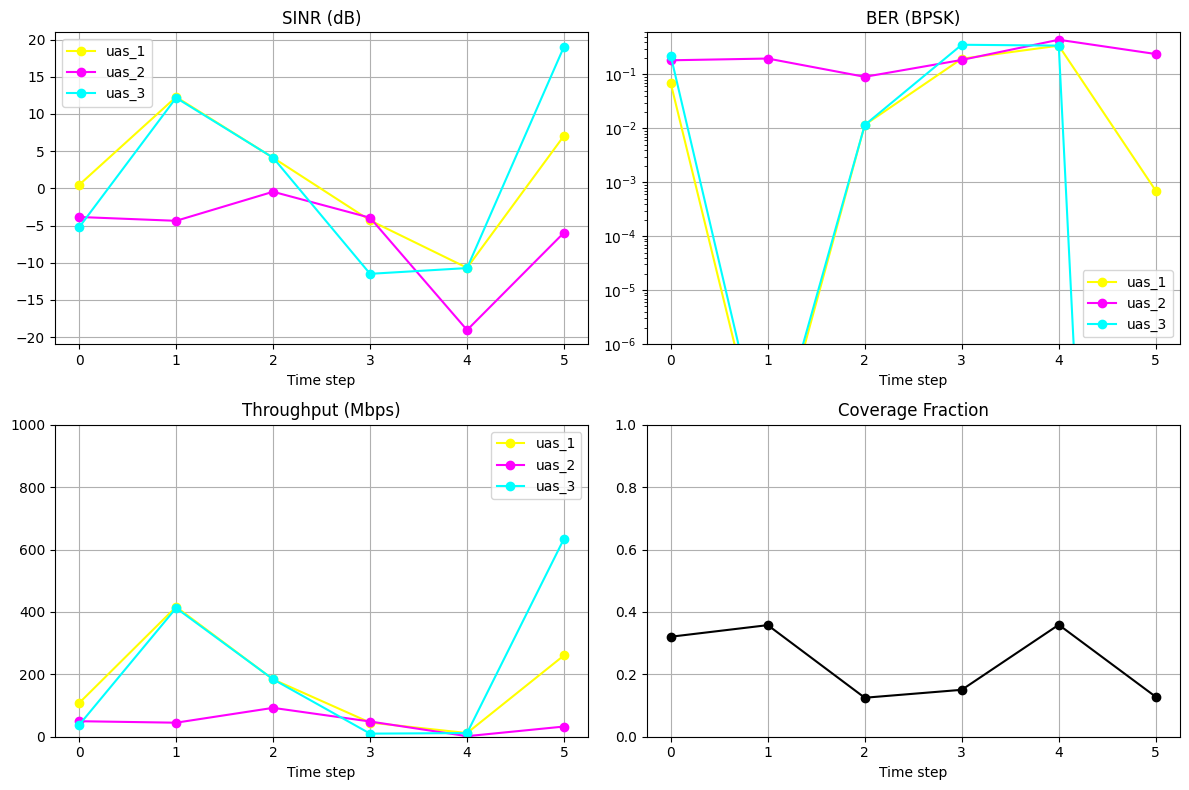

In [9]:
# -----------------------------
# PLOT KPIs
# -----------------------------
plot_kpis(kpi_log, scene)